In [136]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller
from scipy.stats import boxcox



In [97]:
dataframe = pd.read_csv("/Users/v/Data Science Projects/time-series-project/data/train.csv")


check data integrity 

In [98]:
dataframe.info()
#need to convert the columns with dates to datetime 

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [99]:
#dataframe["Order Date"] = pd.to_datetime(dataframe["Order Date"], dayfirst=True)

In [100]:
#postal code needs imputation, but you cannot just impute postal codes plus they are a useless feature so you might just end up dropping those columns 
dataframe[dataframe["Postal Code"].isna()]


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
2234,2235,CA-2018-104066,05/12/2018,10/12/2018,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10001013,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,205.03
5274,5275,CA-2016-162887,07/11/2016,09/11/2016,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,Vermont,NaN,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20
8798,8799,US-2017-150140,06/04/2017,10/04/2017,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,Vermont,NaN,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75
9146,9147,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98
9147,9148,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04
9148,9149,US-2017-165505,23/01/2017,27/01/2017,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29
9386,9387,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10000157,Office Supplies,Paper,Xerox 191,79.92
9387,9388,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28
9388,9389,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94
9389,9390,US-2018-127292,19/01/2018,23/01/2018,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04


In [101]:
dataframe.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [102]:
dataframe['Product Name'].describe()

count                9800
unique               1849
top       Staple envelope
freq                   47
Name: Product Name, dtype: object

In [103]:
dataframe[dataframe.duplicated()]
dataframe.duplicated().sum()
#no duplicates

np.int64(0)

In [104]:
#plot the data
dataframe["Order Date"] = pd.to_datetime(dataframe["Order Date"], dayfirst=True)
dataframe = dataframe.set_index("Order Date")

In [105]:
print(type(dataframe.index))

<class 'pandas.DatetimeIndex'>


In [154]:
dataframe["Sales"].resample(rule="ME").sum()

Order Date
2015-01-31     14205.7070
2015-02-28      4519.8920
2015-03-31     55205.7970
2015-04-30     27906.8550
2015-05-31     23644.3030
2015-06-30     34322.9356
2015-07-31     33781.5430
2015-08-31     27117.5365
2015-09-30     81623.5268
2015-10-31     31453.3930
2015-11-30     77907.6607
2015-12-31     68167.0585
2016-01-31     18066.9576
2016-02-29     11951.4110
2016-03-31     32339.3184
2016-04-30     34154.4685
2016-05-31     29959.5305
2016-06-30     23599.3740
2016-07-31     28608.2590
2016-08-31     36818.3422
2016-09-30     63133.6060
2016-10-31     31011.7375
2016-11-30     75249.3995
2016-12-31     74543.6012
2017-01-31     18542.4910
2017-02-28     22978.8150
2017-03-31     51165.0590
2017-04-30     38679.7670
2017-05-31     56656.9080
2017-06-30     39724.4860
2017-07-31     38320.7830
2017-08-31     30542.2003
2017-09-30     69193.3909
2017-10-31     59583.0330
2017-11-30     79066.4958
2017-12-31     95739.1210
2018-01-31     43476.4740
2018-02-28     19920.9974
2

In [151]:
monthly_sales = dataframe["Sales"].resample(rule="ME").sum()
print(type(monthly_sales.index))
monthly_sales.head()

<class 'pandas.DatetimeIndex'>


Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

In [108]:
print(type(monthly_sales.index))
print(monthly_sales.index[:5])
monthly_sales.index = pd.to_datetime(monthly_sales.index)

<class 'pandas.DatetimeIndex'>
DatetimeIndex(['2015-01-31', '2015-02-28', '2015-03-31', '2015-04-30',
               '2015-05-31'],
              dtype='datetime64[us]', name='Order Date', freq='ME')


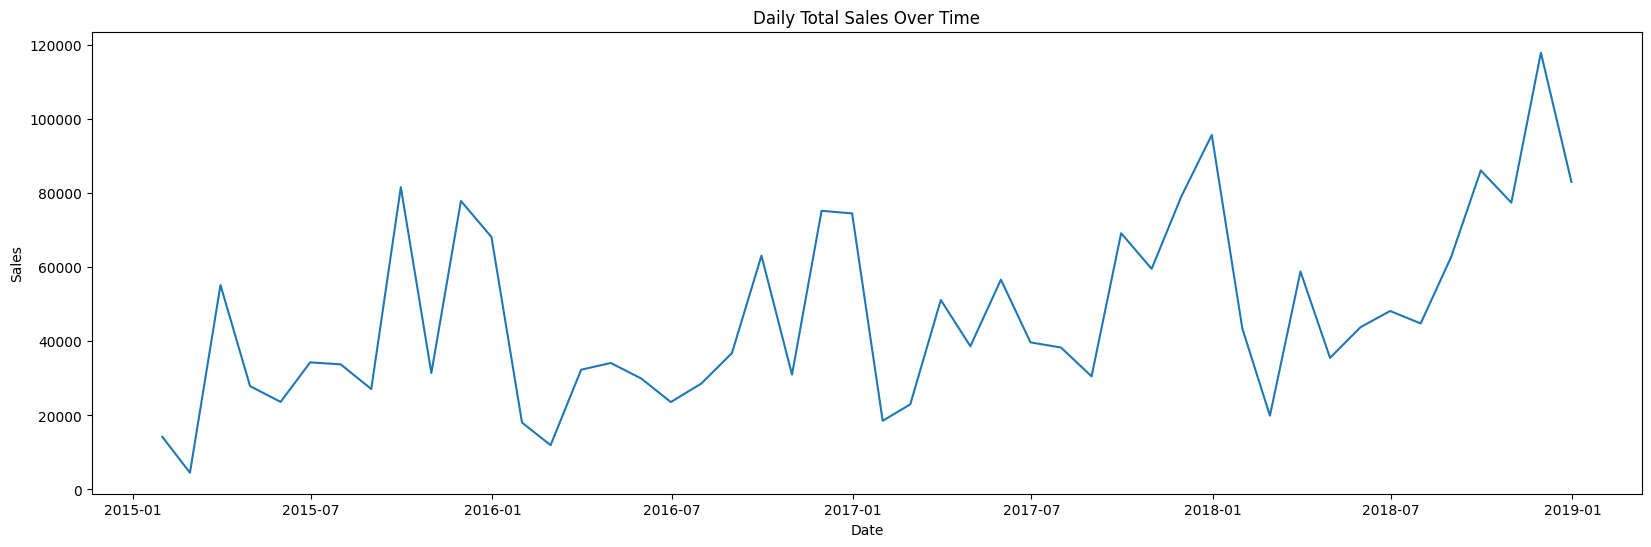

In [109]:
plt.figure(figsize=(20,6))
plt.plot(monthly_sales.index, monthly_sales.values)
plt.title("Daily Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

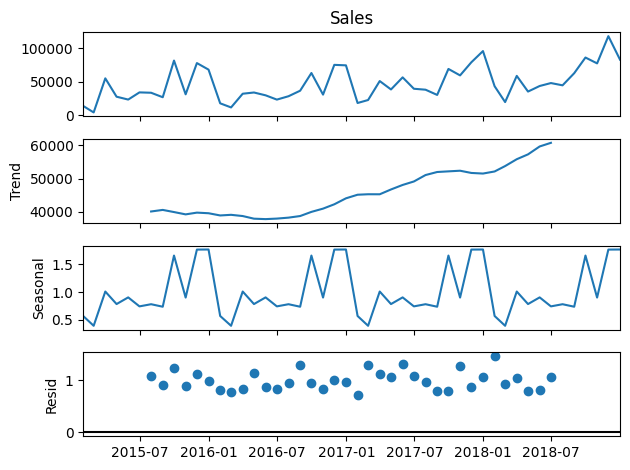

In [121]:
#decompose the series
#i can see that there is clearly seasonaality roughly a trend and seasonality but i should still decompose to inspect it
decomposition_plot_multi = seasonal_decompose(monthly_sales, model= 'multiplicative')
decomposition_plot_multi.plot()
plt. show()

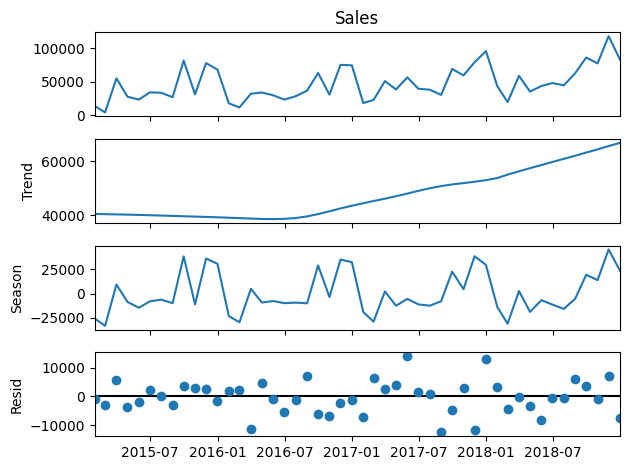

In [123]:
stl = STL(monthly_sales, period=12)
result = stl.fit()
result.plot()
plt.show()

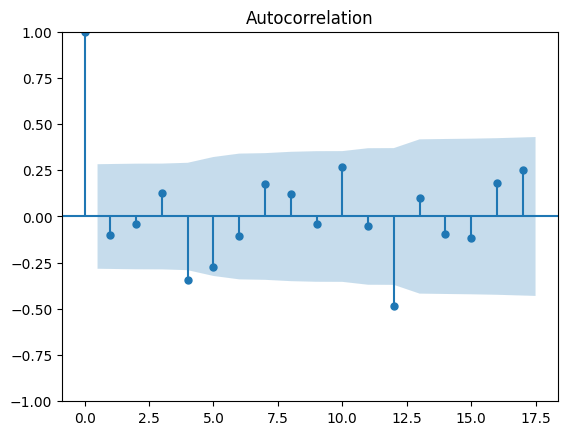

In [124]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(result.resid.dropna())
plt.show()

<Axes: xlabel='Order Date'>

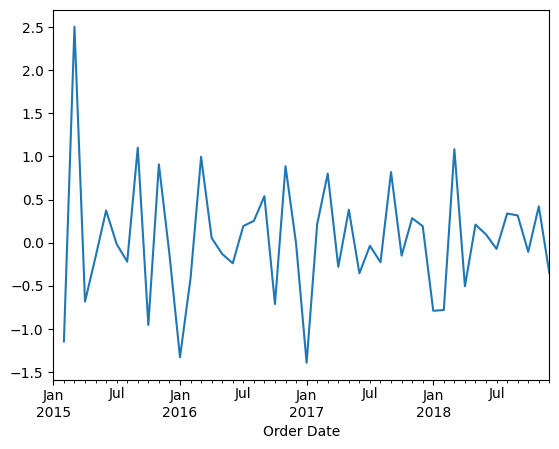

In [146]:
#check stationailty
log_data = np.log(monthly_sales)
log_diff_data = log_data.diff()
log_diff_data.plot()

In [147]:
def adf_test(series):
    """ADF test for stationarity"""

    test_results = adfuller(series.dropna())

    print('ADF Statistic:', test_results[0])
    print('P-Value:', test_results[1])
    print('Critical Values:')

    for thres, adf_stat in test_results[4].items():
        print(f'\t{thres}: {adf_stat:.2f}')

adf_test(log_diff_data)

ADF Statistic: -9.02395024270846
P-Value: 5.676336023093459e-15
Critical Values:
	1%: -3.63
	5%: -2.95
	10%: -2.61


0.45241910034833555


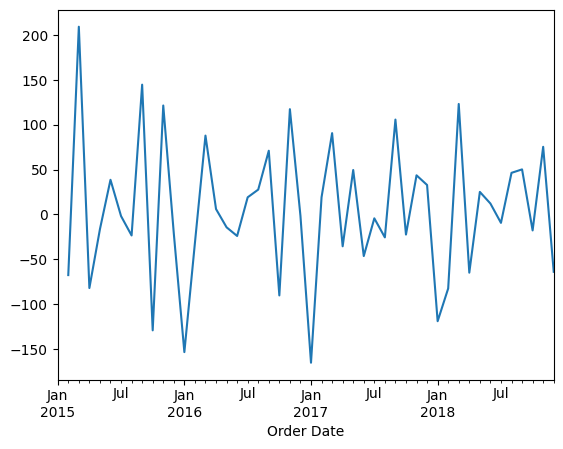

In [148]:
#check stationailty
log_data,lam = boxcox(monthly_sales)
log_data = pd.Series(
    log_data,
    index=monthly_sales.index
)
log_diff_data = log_data.diff()
log_diff_data.plot()
print(lam)

In [149]:
# ADF test


def adf_test(series):
    """ADF test for stationarity"""

    test_results = adfuller(series.dropna())

    print('ADF Statistic:', test_results[0])
    print('P-Value:', test_results[1])
    print('Critical Values:')

    for thres, adf_stat in test_results[4].items():
        print(f'\t{thres}: {adf_stat:.2f}')

adf_test(log_diff_data)


ADF Statistic: -9.106455162141975
P-Value: 3.492015371905589e-15
Critical Values:
	1%: -3.63
	5%: -2.95
	10%: -2.61


Box-Cox transform is better and should thus be used

data is now stationary

now begin the Autocorrelation analysis: acf and pacf
this is done just to visualise. in the pipeline i will use cross validation to select p and q